# Session 3: Naive Bayes for Fake News Detection

**Fake News Detection on Twitter — Model Landscape, Part 3**

By the end of this notebook you will be able to:
- State Bayes' theorem and explain the "naive" conditional-independence assumption
- Hand-compute a tiny Naive Bayes prediction so the math isn't a black box
- Train and evaluate a Multinomial Naive Bayes classifier on tweet data
- Compare Naive Bayes against Logistic Regression and SVM on identical data, using cross-validation

> **Recap:** Logistic Regression and SVM are both **linear discriminative** models — they learn a decision boundary directly. Naive Bayes takes a completely different philosophy: it's a **generative probabilistic** model. Instead of learning a boundary, it asks: *"If I assume each class generates words with certain probabilities, which class was more likely to have generated this tweet?"*

## 0. Setup

We rebuild the same dataset and cleaning pipeline used in Sessions 1 and 2, so this notebook runs standalone.

In [5]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 4)
print("Libraries loaded.")

Libraries loaded.


In [7]:
# ============================================================
# LOAD THE CLEANED DATASET (output of preprocessing stage)
# ============================================================
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

df = pd.read_csv("cleaned_fake_news_dataset.csv")

print("Loaded shape:", df.shape)
print(df.head())


# ============================================================
# TRAIN/TEST SPLIT — before vectorizing, to avoid data leakage
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    df["final_text"], df["label_num"],
    test_size=0.2, random_state=42, stratify=df["label_num"]
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Loaded shape: (38590, 3)
                                          final_text label  label_num
0  st century wire say ben stein reputable profes...  Fake          1
1  washington reuters u president donald trump re...  Real          0
2  reuters puerto rico governor ricardo rossello ...  Real          0
3  monday donald trump embarrassed country accide...  Fake          1
4  glasgow scotland reuters u presidential candid...  Real          0
Train size: 30872
Test size: 7718


In [8]:
# def clean_text(text):
#     text = text.lower()
#     text = re.sub(r"http\S+|www\S+", "", text)
#     text = re.sub(r"#\w+", "", text)
#     text = re.sub(r"@\w+", "", text)
#     text = re.sub(r"[^a-z\s]", "", text)
#     text = re.sub(r"\s+", " ", text).strip()
#     return text

# df['clean_text'] = df['text'].apply(clean_text)
# df['label_num'] = df['label'].map({'Real': 0, 'Fake': 1})

# X_train, X_test, y_train, y_test = train_test_split(
#     df['clean_text'], df['label_num'],
#     test_size=0.2, random_state=42, stratify=df['label_num']
# )

# print("Train size:", X_train.shape[0])
# print("Test size:", X_test.shape[0])

## 1. The Core Idea: Bayes' Theorem

Everything in this model rests on one identity from probability theory:

$$P(\text{class} \mid \text{tweet}) = \frac{P(\text{tweet} \mid \text{class}) \cdot P(\text{class})}{P(\text{tweet})}$$

In words:

$$\underbrace{P(\text{Fake} \mid \text{tweet})}_{\text{posterior — what we want}} = \frac{\overbrace{P(\text{tweet} \mid \text{Fake})}^{\text{likelihood}} \cdot \overbrace{P(\text{Fake})}^{\text{prior}}}{\underbrace{P(\text{tweet})}_{\text{evidence}}}$$

- **Prior** $P(\text{Fake})$ — how common are fake tweets *before* we even look at the words? (Just the class frequency in training data.)
- **Likelihood** $P(\text{tweet} \mid \text{Fake})$ — if a tweet really is fake, how likely is it to contain exactly these words?
- **Evidence** $P(\text{tweet})$ — the overall probability of seeing this exact tweet, regardless of class. This is the same for both classes being compared, so it cancels out when we just want to know which class is *more* likely (we don't need its actual value).

So in practice, we only ever need to compare:

$$P(\text{Fake} \mid \text{tweet}) \ \propto \ P(\text{tweet} \mid \text{Fake}) \cdot P(\text{Fake})$$
$$P(\text{Real} \mid \text{tweet}) \ \propto \ P(\text{tweet} \mid \text{Real}) \cdot P(\text{Real})$$

and predict whichever class gives the larger value.

## 2. Why "Naive"? The Independence Assumption

A tweet is a *sequence* of words: $\text{tweet} = (w_1, w_2, \dots, w_n)$.

Computing the true $P(\text{tweet} \mid \text{class})$ would require modeling how every word's probability depends on every other word in the tweet — this is computationally intractable for any real vocabulary.

**Naive Bayes makes a simplifying (and technically wrong, but very useful) assumption:** every word in the tweet is conditionally independent of every other word, given the class.

$$P(\text{tweet} \mid \text{class}) = P(w_1, w_2, \dots, w_n \mid \text{class}) \ \approx \ \prod_{i=1}^{n} P(w_i \mid \text{class})$$

This means we've reduced an intractable joint-probability problem into something we *can* estimate: just the probability of each individual word appearing, given the class.

**Is this assumption actually true?** No — obviously "secretly" and "controlling" are more likely to co-occur in a fake tweet than independence would suggest. But here's the key practical insight worth telling your students: **Naive Bayes often classifies well even when the independence assumption is technically violated**, because for classification we only need the *relative ordering* of $P(\text{Fake}\mid\text{tweet})$ vs $P(\text{Real}\mid\text{tweet})$ to be correct — not the exact probability values. The errors introduced by the naive assumption tend to affect both classes' scores in similar ways, so the comparison often still comes out right.

## 3. Estimating the Pieces from Training Data

### The prior
$$P(\text{Fake}) = \frac{\text{number of Fake tweets in training data}}{\text{total tweets in training data}}$$

This is just the class frequency — no modeling involved.

### The word likelihoods
For **Multinomial Naive Bayes** (the standard variant for text, used by `sklearn`'s `MultinomialNB`), each word's likelihood given a class is estimated as:

$$P(w_i \mid \text{class}) = \frac{\text{count of } w_i \text{ in all class tweets} + \alpha}{\text{total word count in all class tweets} + \alpha \cdot |V|}$$

Where:
- $\alpha$ is a smoothing constant (almost always $\alpha = 1$, called **Laplace/add-one smoothing**)
- $|V|$ is the vocabulary size

**Why do we need smoothing at all?** Without it, if a word never appeared in the "Real" training tweets, $P(w_i \mid \text{Real}) = 0$. Multiplying by zero would force the *entire product* in the independence formula to zero — one unseen word would override every other piece of evidence in the tweet, no matter how strongly everything else pointed the other way. Smoothing assigns a small non-zero probability to every word for every class, so a single rare word can't break the whole prediction.

## 4. A Tiny Worked Example (By Hand)

Before training on real tweets, let's compute a Naive Bayes prediction completely by hand on a tiny 4-document toy corpus — small enough to verify every number ourselves.

In [9]:
# A deliberately tiny corpus, small enough to verify every probability by hand
toy_docs = [
    "breaking shocking secret truth",       # Fake
    "secretly hidden agenda exposed",       # Fake
    "officials confirmed new policy",       # Real
    "reuters reported quarterly earnings",  # Real
]
toy_labels = [1, 1, 0, 0]  # 1 = Fake, 0 = Real

toy_vec = CountVectorizer()
toy_X = toy_vec.fit_transform(toy_docs)

print("Vocabulary:", toy_vec.get_feature_names_out())
print("\nWord count matrix (rows = documents, columns = vocabulary words):")
print(toy_X.toarray())

Vocabulary: ['agenda' 'breaking' 'confirmed' 'earnings' 'exposed' 'hidden' 'new'
 'officials' 'policy' 'quarterly' 'reported' 'reuters' 'secret' 'secretly'
 'shocking' 'truth']

Word count matrix (rows = documents, columns = vocabulary words):
[[0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1]
 [1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0]]


In [10]:
toy_nb = MultinomialNB(alpha=1.0)
toy_nb.fit(toy_X, toy_labels)

print("Class priors -> P(Real) =", np.exp(toy_nb.class_log_prior_[0]).round(4),
      " P(Fake) =", np.exp(toy_nb.class_log_prior_[1]).round(4))

# Inspect a couple of individual word likelihoods
for word in ["secret", "officials", "shocking"]:
    idx = toy_vec.vocabulary_[word]
    p_real = np.exp(toy_nb.feature_log_prob_[0][idx])
    p_fake = np.exp(toy_nb.feature_log_prob_[1][idx])
    print(f"P('{word}' | Real) = {p_real:.4f}   P('{word}' | Fake) = {p_fake:.4f}")

Class priors -> P(Real) = 0.5  P(Fake) = 0.5
P('secret' | Real) = 0.0417   P('secret' | Fake) = 0.0833
P('officials' | Real) = 0.0833   P('officials' | Fake) = 0.0417
P('shocking' | Real) = 0.0417   P('shocking' | Fake) = 0.0833


Notice: `"secret"` and `"shocking"` have higher likelihood under Fake than Real, while `"officials"` is the reverse — exactly matching the intuition that institutional language signals Real and sensational language signals Fake.

Now let's classify a brand new tiny tweet by hand, using the independence assumption directly, and confirm it matches what `sklearn` computes internally.

In [11]:
test_tweet = ["secret shocking news"]
test_vec = toy_vec.transform(test_tweet)
print("Test tweet word counts:", dict(zip(toy_vec.get_feature_names_out(), test_vec.toarray()[0])))

# --- Manual calculation using the independence assumption ---
# log P(class | tweet) propto log P(class) + sum_i [ count(w_i) * log P(w_i | class) ]
log_score_real = toy_nb.class_log_prior_[0]
log_score_fake = toy_nb.class_log_prior_[1]

counts = test_vec.toarray()[0]
log_score_real += np.sum(counts * toy_nb.feature_log_prob_[0])
log_score_fake += np.sum(counts * toy_nb.feature_log_prob_[1])

print(f"\nManual log-score for Real: {log_score_real:.4f}")
print(f"Manual log-score for Fake: {log_score_fake:.4f}")
print("Manual prediction:", "FAKE" if log_score_fake > log_score_real else "REAL")

# --- Compare against sklearn's own prediction ---
sklearn_pred = toy_nb.predict(test_vec)[0]
sklearn_proba = toy_nb.predict_proba(test_vec)[0]
print(f"\nsklearn prediction: {'FAKE' if sklearn_pred == 1 else 'REAL'}")
print(f"sklearn P(Real)={sklearn_proba[0]:.4f}  P(Fake)={sklearn_proba[1]:.4f}")
print("\n-> Our hand calculation and sklearn agree on which class scores higher.")

Test tweet word counts: {'agenda': np.int64(0), 'breaking': np.int64(0), 'confirmed': np.int64(0), 'earnings': np.int64(0), 'exposed': np.int64(0), 'hidden': np.int64(0), 'new': np.int64(0), 'officials': np.int64(0), 'policy': np.int64(0), 'quarterly': np.int64(0), 'reported': np.int64(0), 'reuters': np.int64(0), 'secret': np.int64(1), 'secretly': np.int64(0), 'shocking': np.int64(1), 'truth': np.int64(0)}

Manual log-score for Real: -7.0493
Manual log-score for Fake: -5.6630
Manual prediction: FAKE

sklearn prediction: FAKE
sklearn P(Real)=0.2000  P(Fake)=0.8000

-> Our hand calculation and sklearn agree on which class scores higher.


**Why we use log-probabilities instead of raw probabilities:** multiplying many small probabilities together (one per word) quickly produces an extremely tiny number that can underflow to zero in floating-point arithmetic. Taking logs turns the product into a *sum*, which is numerically stable — this is a purely computational trick, it doesn't change which class wins.

## 5. Training Naive Bayes on Real Tweet Data

### A note on vectorization choice

Naive Bayes is traditionally paired with **`CountVectorizer`** (raw word counts) rather than TF-IDF, because the Multinomial Naive Bayes model is explicitly derived assuming word **counts** — that's what the formula in Section 3 expects. TF-IDF values are weighted, continuous numbers, which technically violates the model's count-based assumptions.

In practice, `MultinomialNB` still runs on TF-IDF input (`sklearn` won't stop you), and often performs similarly. We'll train it both ways below and compare, so your students can see this isn't just a theoretical footnote.

In [12]:
count_vectorizer = CountVectorizer(max_features=3000)
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)

tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("CountVectorizer matrix shape:", X_train_counts.shape)
print("TF-IDF matrix shape:", X_train_tfidf.shape)

CountVectorizer matrix shape: (30872, 3000)
TF-IDF matrix shape: (30872, 3000)


In [13]:
# Naive Bayes with CountVectorizer (the textbook-correct pairing)
nb_counts = MultinomialNB(alpha=1.0)
nb_counts.fit(X_train_counts, y_train)
y_pred_counts = nb_counts.predict(X_test_counts)

# Naive Bayes with TF-IDF (commonly done in practice, despite the theoretical mismatch)
nb_tfidf = MultinomialNB(alpha=1.0)
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = nb_tfidf.predict(X_test_tfidf)

print(f"Naive Bayes + CountVectorizer accuracy: {accuracy_score(y_test, y_pred_counts):.4f}")
print(f"Naive Bayes + TF-IDF accuracy:          {accuracy_score(y_test, y_pred_tfidf):.4f}")

Naive Bayes + CountVectorizer accuracy: 0.9469
Naive Bayes + TF-IDF accuracy:          0.9316


For the rest of this notebook we'll use the **CountVectorizer version**, since it matches the model's underlying assumptions and is the standard practice for Naive Bayes text classification.

## 6. Evaluating the Model

In [14]:
nb_model = nb_counts  # use this going forward
y_pred_nb = y_pred_counts

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print(f"Accuracy:  {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall:    {rec_nb:.4f}")
print(f"F1-score:  {f1_nb:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred_nb, target_names=["Real", "Fake"]))

Accuracy:  0.9469
Precision: 0.9388
Recall:    0.9437
F1-score:  0.9412

Full classification report:
              precision    recall  f1-score   support

        Real       0.95      0.95      0.95      4238
        Fake       0.94      0.94      0.94      3480

    accuracy                           0.95      7718
   macro avg       0.95      0.95      0.95      7718
weighted avg       0.95      0.95      0.95      7718



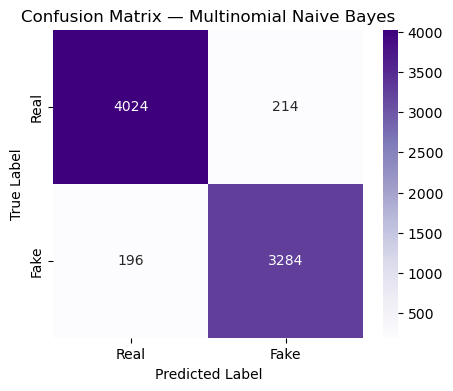

In [15]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Multinomial Naive Bayes")
plt.show()

## 7. Interpreting the Model: Most Informative Words

Just like Logistic Regression's weights, Naive Bayes gives us a number per word per class (`feature_log_prob_`). A useful way to read this is the **log-likelihood ratio** between classes — how much more likely a word is to appear in Fake tweets vs Real tweets (or vice versa).

In [16]:
feature_names = np.array(count_vectorizer.get_feature_names_out())

log_prob_real = nb_model.feature_log_prob_[0]   # log P(word | Real)
log_prob_fake = nb_model.feature_log_prob_[1]   # log P(word | Fake)

# Log-likelihood ratio: positive = more associated with Fake, negative = more associated with Real
llr = log_prob_fake - log_prob_real

top_fake_idx = np.argsort(llr)[-15:][::-1]
top_real_idx = np.argsort(llr)[:15]

print("Words most strongly associated with FAKE:")
for idx in top_fake_idx:
    print(f"  {feature_names[idx]:<15} log-likelihood ratio = {llr[idx]:.3f}")

print("\nWords most strongly associated with REAL:")
for idx in top_real_idx:
    print(f"  {feature_names[idx]:<15} log-likelihood ratio = {llr[idx]:.3f}")

Words most strongly associated with FAKE:
  belowfeatured   log-likelihood ratio = 6.352
  getty           log-likelihood ratio = 6.346
  flickr          log-likelihood ratio = 6.192
  screenshot      log-likelihood ratio = 5.789
  reilly          log-likelihood ratio = 5.459
  bundy           log-likelihood ratio = 5.041
  cop             log-likelihood ratio = 4.224
  hannity         log-likelihood ratio = 4.172
  gop             log-likelihood ratio = 3.976
  rant            log-likelihood ratio = 3.619
  wire            log-likelihood ratio = 3.476
  disgusting      log-likelihood ratio = 3.412
  literally       log-likelihood ratio = 3.403
  image           log-likelihood ratio = 3.380
  gon             log-likelihood ratio = 3.377

Words most strongly associated with REAL:
  rohingya        log-likelihood ratio = -6.457
  myanmar         log-likelihood ratio = -6.373
  rakhine         log-likelihood ratio = -6.319
  puigdemont      log-likelihood ratio = -6.077
  fdp             

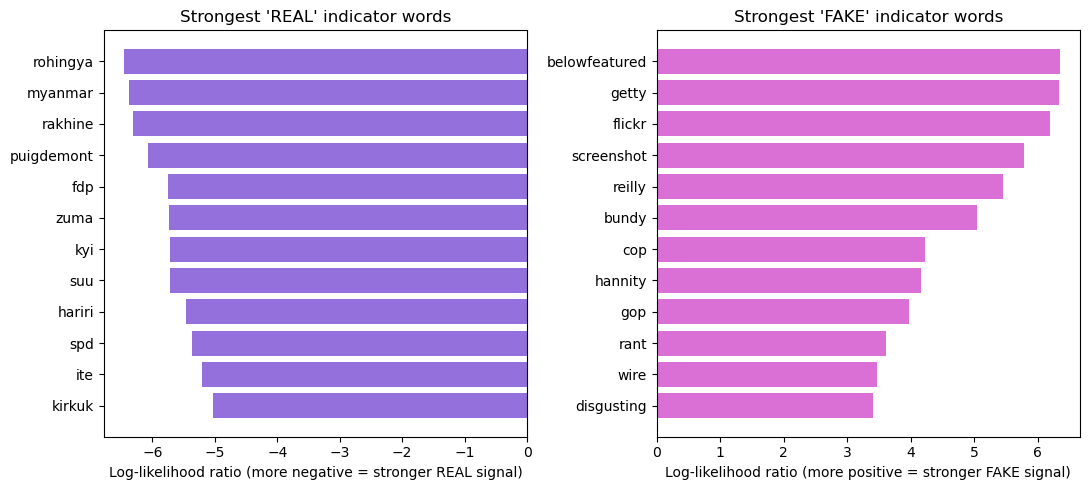

In [17]:
top_n = 12
fake_words = feature_names[top_fake_idx[:top_n]]
fake_llr = llr[top_fake_idx[:top_n]]
real_words = feature_names[top_real_idx[:top_n]]
real_llr = llr[top_real_idx[:top_n]]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].barh(real_words[::-1], real_llr[::-1], color='mediumpurple')
axes[0].set_title("Strongest 'REAL' indicator words")
axes[0].set_xlabel("Log-likelihood ratio (more negative = stronger REAL signal)")

axes[1].barh(fake_words[::-1], fake_llr[::-1], color='orchid')
axes[1].set_title("Strongest 'FAKE' indicator words")
axes[1].set_xlabel("Log-likelihood ratio (more positive = stronger FAKE signal)")

plt.tight_layout()
plt.show()

**Discussion point for your students:** compare this list against the Logistic Regression word-weight list from Session 1. The two models are estimating completely different mathematical quantities (likelihood ratios vs. linear-model coefficients), yet they tend to surface very similar words. That convergence is itself evidence that the signal genuinely exists in the data — it isn't an artifact of either model's particular assumptions.

## 8. Try It Yourself: Predict on a New Tweet

In [18]:
def predict_tweet_nb(raw_text, model=nb_model, vec=count_vectorizer):
    cleaned = clean_text(raw_text)
    vec_form = vec.transform([cleaned])
    prob_fake = model.predict_proba(vec_form)[0][1]
    label = "FAKE" if prob_fake >= 0.5 else "REAL"
    return label, prob_fake

test_tweet = "Officials confirmed the new policy will take effect next month"
label, prob = predict_tweet_nb(test_tweet)
print(f"Tweet: {test_tweet}")
print(f"Prediction: {label}  (P(Fake) = {prob:.3f})")

print()
test_tweet_2 = "SHOCKING you wont believe what they are secretly hiding from everyone"
label2, prob2 = predict_tweet_nb(test_tweet_2)
print(f"Tweet: {test_tweet_2}")
print(f"Prediction: {label2}  (P(Fake) = {prob2:.3f})")

Tweet: Officials confirmed the new policy will take effect next month
Prediction: REAL  (P(Fake) = 0.101)

Tweet: SHOCKING you wont believe what they are secretly hiding from everyone
Prediction: FAKE  (P(Fake) = 0.992)


## 9. Why Naive Bayes Is a Reasonable Choice for Text — and Where It Falls Short

**Why it works:**
1. **Extremely fast to train.** Fitting is just counting word occurrences per class and normalizing — no iterative optimization (no gradient descent, no margin search). This matters at scale: classifying millions of tweets per day favors models that are cheap to retrain frequently.
2. **Works well with limited data.** Because it estimates simple per-word statistics rather than a high-dimensional weight vector, it can perform reasonably even with a relatively small labeled dataset.
3. **Naturally probabilistic and multi-class ready.** Extending to more than two classes (e.g. "Real" / "Satire" / "Fake" / "Misleading-but-partially-true") is trivial — just add more classes to the prior and likelihood estimation. Logistic Regression and SVM need extra machinery (one-vs-rest, softmax) to do the same.

**Where it falls short:**
1. **The independence assumption is genuinely violated by language.** Phrases like *"big pharma"* or *"wake up"* carry meaning as a unit; treating each word as independent throws away that structure.
2. **It tends to be less accurate than discriminative models like Logistic Regression or SVM** on tasks where word *combinations* matter more than individual word frequencies — which is part of why the project benchmark showed Naive Bayes with the lowest accuracy of the three (88.1%) in the original deck.
3. **Calibration is often poor.** Naive Bayes probabilities tend to be overconfident (very close to 0 or 1) because the independence assumption causes evidence from individual words to compound multiplicatively, even when those words aren't truly independent.

## 10. Head-to-Head: Naive Bayes vs Logistic Regression vs SVM

Let's put all three models side by side, the same way the project's benchmark slide does — but this time backed by 5-fold cross-validation, not just a single train/test split, so we can see whether the differences are real or just noise.

In [19]:
lr_full = LogisticRegression(max_iter=1000)
svm_full = LinearSVC(max_iter=5000)

lr_full.fit(X_train_tfidf, y_train)
svm_full.fit(X_train_tfidf, y_train)

lr_pred = lr_full.predict(X_test_tfidf)
svm_pred = svm_full.predict(X_test_tfidf)

comparison_table = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Linear SVM"],
    "Accuracy": [accuracy_score(y_test, y_pred_nb), accuracy_score(y_test, lr_pred), accuracy_score(y_test, svm_pred)],
    "Precision": [precision_score(y_test, y_pred_nb), precision_score(y_test, lr_pred), precision_score(y_test, svm_pred)],
    "Recall": [recall_score(y_test, y_pred_nb), recall_score(y_test, lr_pred), recall_score(y_test, svm_pred)],
    "F1-score": [f1_score(y_test, y_pred_nb), f1_score(y_test, lr_pred), f1_score(y_test, svm_pred)],
})
comparison_table

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.946877,0.938822,0.943678,0.941244
1,Logistic Regression,0.986266,0.990407,0.979023,0.984682
2,Linear SVM,0.991967,0.993931,0.988218,0.991066


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    df['final_text'], df['label_num'],
    test_size=0.2, random_state=42, stratify=df['label_num']
)


X_all_counts = count_vectorizer.transform(df['final_text'])
X_all_tfidf = tfidf_vectorizer.transform(df['final_text'])
y_all = df['label_num']

nb_cv_scores = cross_val_score(MultinomialNB(), X_all_counts, y_all, cv=5, scoring='accuracy')
lr_cv_scores = cross_val_score(LogisticRegression(max_iter=1000), X_all_tfidf, y_all, cv=5, scoring='accuracy')
svm_cv_scores = cross_val_score(LinearSVC(max_iter=5000), X_all_tfidf, y_all, cv=5, scoring='accuracy')

cv_results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Linear SVM"],
    "CV Mean Accuracy": [nb_cv_scores.mean(), lr_cv_scores.mean(), svm_cv_scores.mean()],
    "CV Std Dev": [nb_cv_scores.std(), lr_cv_scores.std(), svm_cv_scores.std()],
})
print(cv_results)
print()
print("Per-fold scores:")
print("Naive Bayes:         ", np.round(nb_cv_scores, 4))
print("Logistic Regression: ", np.round(lr_cv_scores, 4))
print("Linear SVM:           ", np.round(svm_cv_scores, 4))

                 Model  CV Mean Accuracy  CV Std Dev
0          Naive Bayes          0.946644    0.005921
1  Logistic Regression          0.985255    0.001583
2           Linear SVM          0.991578    0.000441

Per-fold scores:
Naive Bayes:          [0.9381 0.9435 0.949  0.9467 0.9559]
Logistic Regression:  [0.9821 0.9861 0.9859 0.9857 0.9864]
Linear SVM:            [0.9911 0.9914 0.9917 0.9913 0.9924]


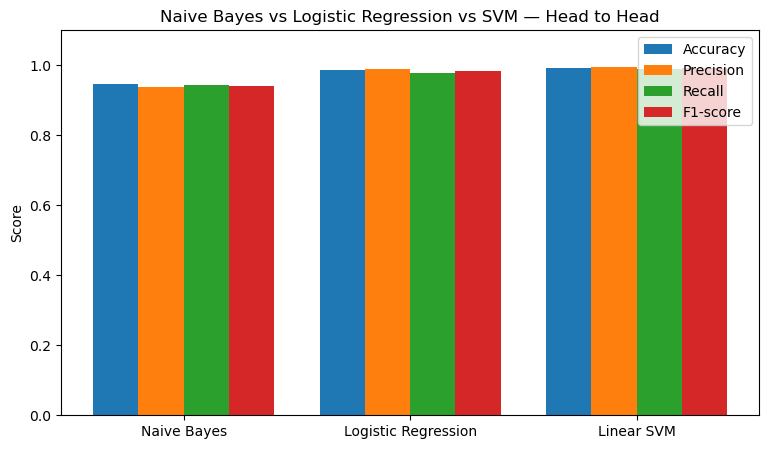

In [27]:
x = np.arange(len(comparison_table))
width = 0.2
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
colors = ['mediumpurple', 'steelblue', 'indianred']

fig, ax = plt.subplots(figsize=(9, 5))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, comparison_table[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_table["Model"])
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Naive Bayes vs Logistic Regression vs SVM — Head to Head")
ax.legend()
plt.show()

**Teaching takeaway, tying back to the project deck's benchmark slide (Naive Bayes 88.1%, Logistic Regression 92.4%, SVM 94.8%):** look at whether the cross-validation standard deviations overlap. If they do, the ranking between models on any single split could easily flip with different data — the *true* lesson isn't "SVM is the best model," it's "all three are reasonable choices, and the right one depends on your priorities":

- Need **speed** and a simple, interpretable probabilistic baseline → **Naive Bayes**
- Need **interpretability** and well-calibrated probabilities → **Logistic Regression**
- Need the best raw accuracy on borderline/ambiguous cases and don't mind giving up native probability outputs → **SVM**

## 11. Summary

| Concept | Key Idea |
|---|---|
| Bayes' theorem | $P(\text{class}\mid\text{tweet}) \propto P(\text{tweet}\mid\text{class}) \cdot P(\text{class})$ |
| "Naive" assumption | Treats every word as conditionally independent given the class — technically wrong, practically useful |
| Prior | Simple class frequency in training data |
| Likelihood | Per-word probability estimated from word counts, with Laplace smoothing to avoid zero probabilities |
| Log-space computation | Sums of logs instead of products of probabilities, to avoid numerical underflow |
| Vectorizer pairing | `CountVectorizer` matches the model's theoretical assumptions better than TF-IDF |
| Interpretability | Log-likelihood ratios reveal which words are most associated with each class |
| Strengths | Extremely fast, works with limited data, naturally multi-class |
| Weaknesses | Independence assumption ignores word combinations; often lower accuracy than discriminative linear models; probabilities tend to be overconfident |

### What's next
You've now covered all three models from the project's "Model Landscape" slide: **Logistic Regression, SVM, and Naive Bayes.** The natural next step in the course is the **Performance Metrics deep-dive** — going beyond just computing precision/recall/F1, into *why* the choice between optimizing for precision vs. recall matters specifically for fake news detection (e.g., is it worse to miss a fake tweet, or to wrongly flag a real one as fake?), and finally assembling the complete benchmark comparison table that mirrors the project deck's results slide.